# 1st Workflow: HUA Workflow (Housing Unit Analysis)

## Loading the Community

In [1]:
# To reload submodules need to use this magic command to set autoreload on
%load_ext autoreload
%autoreload 2
from pyncoda.ncoda_00g_community_options import *
from IPython.display import display

In [2]:
# select a community from this list
# if your community is not in this list, add it to the file ncoda_00g_community_options.py
list_community_options(communities_dictionary)

['Lumberton, NC: IN-CORE Building inventory for Robeson County, NC',
 'Galveston, TX: IN-CORE Building inventory for Galveston County, TX',
 'Galveston, TX: NSI Building inventory for Galveston County, TX',
 'Galveston, TX: IN-CORE Building inventory for Galveston Island, TX',
 'Mayfield, KY: NSI Building inventory for Graves County, KY',
 'Beaumont, TX: NSI Building inventory for Jefferson County, TX',
 'Beaumont, TX: Safayet Building inventory for Jefferson County, TX',
 'Pentwater, MI: NSI Building inventory for Oceana County, MI',
 'Seaside, OR: NSI Building inventory for Clatsop County, OR',
 'Lane County, OR: NSI Building inventory for Lane County, OR',
 'Benton County, OR: NSI Building inventory for Benton County, OR',
 'Southeast Texas Urban Integrated Field Lab: NSI Building inventory for Southeast Texas',
 'Southeast Texas Urban Integrated Field Lab (12 neighbor counties): NSI Building inventory for Southeast Texas',
 'Brazos County, TX: NSI Building inventory for Brazos Coun

In [3]:
community_id_by_name = 'Galveston, TX: NSI Building inventory for Galveston County, TX'

In [4]:
community_id, focalplace, countyname, countyfips = get_community_id_by_name(community_id_by_name)
communities = {community_id : communities_dictionary[community_id]}

Selected community ID: Galveston_County_TX_NSI
Galveston, TX is in TEXAS
Focal place: Galveston
Galveston, TX is in Galveston County, TX with FIPS code 48167
Use IN-CORE: False


## Setiing up the Environment

In [5]:
import pandas as pd
import geopandas as gpd # For reading in shapefiles
import numpy as np
import sys # For displaying package versions
import os # For managing directories and file paths if drive is mounted
import scooby # Reports Python environment

import contextily as cx # For adding basemap tiles to plot
import matplotlib.pyplot as plt # For plotting and making graphs

In [6]:
# open, read, and execute python program with reusable commands
from pyncoda.ncoda_00d_cleanvarsutils import *
from pyncoda.ncoda_04c_poptableresults import *
from pyncoda.ncoda_07i_process_communities import process_community_workflow

In [7]:
# Generate report of Python environment
base_packages = ['pandas','ipyleaflet','seaborn','contextily']
incore_packages = ['pyincore','pyincore_viz']
check_packages = base_packages + incore_packages
print(scooby.Report(additional=check_packages))


--------------------------------------------------------------------------------
  Date: Wed Apr 29 23:25:59 2026 Central Daylight Time

                OS : Windows (10 10.0.26200 SP0 Multiprocessor Free)
            CPU(s) : 24
           Machine : AMD64
      Architecture : 64bit
               RAM : 15.7 GiB
       Environment : Jupyter

  Python 3.10.14 | packaged by Anaconda, Inc. | (main, May  6 2024, 19:44:50)
  [MSC v.1916 64 bit (AMD64)]

            pandas : 2.2.2
        ipyleaflet : Module not found
           seaborn : 0.13.2
        contextily : 1.6.0
          pyincore : Module not found
      pyincore_viz : Module not found
             numpy : 1.26.4
             scipy : 1.13.1
           IPython : 8.25.0
        matplotlib : 3.8.4
            scooby : 0.10.0

  Intel(R) oneAPI Math Kernel Library Version 2023.1-Product Build 20230303
  for Intel(R) 64 architecture applications
--------------------------------------------------------------------------------


In [8]:
# Check working directory - good practice for relative path access
os.getcwd()

'D:\\000_Projects_UH\\Disability_HUA-PREC_Workflow'

## Run Housing Unit Allocation
### The following code will produce the following outputs:
1. Housing Unit Inventory
2. Address Point Invento y
3. Housing Unit Allocation

In [9]:
basevintage_options = ['2020']

In [10]:
from pyncoda.ncoda_07i_process_communities import process_community_workflow

In [11]:
hua_hui_gdf_dict = {}
base_seed = 9876
iterations = 2
# iterate through basevintage options to run Monte Carlo Simulation
for basevintage in basevintage_options:
    hua_hui_gdf_dict[basevintage] = {}
    for i in range(iterations):
        seed_i = base_seed + i
        print(f"Running iteration {i+1} of {iterations} for basevintage {basevintage} with seed {seed_i}")
        workflow = process_community_workflow(
                    communities,
                    seed = seed_i,
                    version = '2.1.0',
                    version_text = 'v2-1-0',
                    basevintage = basevintage,
                    outputfolder ="OutputData_HUA",
                    outputfolders = {},
                    savefiles = True)
        hua_hui_gdf_dict[basevintage][seed_i] = workflow.process_communities()

Running iteration 1 of 2 for basevintage 2020 with seed 9876
Generating Housing Unit Inventory v2.0.0 data for Galveston, TX
Galveston County, TX : county FIPS Code 48167
File already exists, skipping: OutputData_HUA/Galveston_County_TX_NSI/../hui_v2-1-0_Galveston_County_TX_NSI_2020_rs9876.csv
Checking output for huid
Checking output for blockid
Checking output for bgid
Checking output for tractid
Checking output for FIPScounty
Checking output for numprec
Checking output for ownershp
Checking output for race
Checking output for hispan
Checking output for family
Checking output for vacancy
Checking output for gqtype
Checking output for incomegroup
Checking output for hhinc
Checking output for randincome
Checking output for poverty
Checking huid Data Type
   Current type: <class 'pandas.core.series.Series'> Expected type <class 'str'>
Checking blockid Data Type
   Current type: <class 'pandas.core.series.Series'> Expected type <class 'str'>
    Length of blockid is correct
Checking bgid 

In [12]:
import os

print("Current working directory:")
print(os.getcwd())

print("\nFiles in this directory:")
print(os.listdir())

Current working directory:
D:\000_Projects_UH\Disability_HUA-PREC_Workflow

Files in this directory:
['.devcontainer', '.git', '.gitattributes', '.github', '.gitignore', '.ipynb_checkpoints', 'Admin', 'Archive', 'CITATION.cff', 'Disability_Galveston_2010', 'environment.yml', 'HUA_Disability_2010.ipynb', 'HUA_Disability_2020.ipynb', 'IN-CORE_HRRC_Banner.png', 'LICENSE', 'ncoda_07fv1_HUA_PREC_NSI_modAZs.ipynb', 'ncoda_07fv3_HUA_PREC_NSI.ipynb', 'ncoda_07gv1_HUI_2020.ipynb', 'ncoda_07hv4_HUA_PREC_NSI.ipynb', 'ncoda_07iv1_SimCenter_HUA.ipynb', 'ncoda_08av1_PyPDFcodebook.ipynb', 'OutputData', 'OutputData_HUA', 'OutputData_PREC', 'pyncoda', 'pyproject.toml', 'Readings', 'README.md', 'requirements.txt', 'requirements_new.txt', 'SampleOutputData', 'temp.csv']


## Explore and Validate Housing Unit Allocation

### Look at population characteristics and compare to US Census

In [13]:
where = communities[community_id]['community_name']
print(where, focalplace, countyname, countyfips)

Galveston, TX Galveston Galveston County, TX 48167


### 2020 - Total Population by Households by Tenure Status (Seed: 9876)

In [14]:
PopResultsTable.pop_results_table(
                  input_df = hua_hui_gdf_dict['2020'][9876], 
                  who = "Total Population by Households", 
                  what = "by Race, Ethnicity",
                  where = countyname,
                  when = '2020 (9876)',
                  row_index = "Race Ethnicity",
                  col_index = 'Tenure Status')

Tenure Status,1 Owner Occupied (%),2 Renter Occupied (%),Total Population by Households (%)
Race Ethnicity,,,
"1 White alone, Not Hispanic","150,085 (62.5%)","46,702 (45.2%)","196,787 (57.3%)"
"2 Black alone, Not Hispanic","19,558 (8.1%)","21,597 (20.9%)","41,155 (12.0%)"
"3 American Indian and Alaska Native alone, Not Hispanic",688 (0.3%),365 (0.4%),"1,053 (0.3%)"
"4 Asian alone, Not Hispanic","9,531 (4.0%)","2,226 (2.2%)","11,757 (3.4%)"
"5 Other Race, Not Hispanic","7,176 (3.0%)","3,418 (3.3%)","10,594 (3.1%)"
"6 Any Race, Hispanic","53,181 (22.1%)","28,980 (28.1%)","82,161 (23.9%)"
Total,"240,219 (100.0%)","103,288 (100.0%)","343,507 (100.0%)"


### 2020 - Total Population by Households by Tenure Status (Seed: 9877)

In [15]:
PopResultsTable.pop_results_table(
                  input_df = hua_hui_gdf_dict['2020'][9877], 
                  who = "Total Population by Households", 
                  what = "by Race, Ethnicity",
                  where = countyname,
                  when = '2020 (9877)',
                  row_index = "Race Ethnicity",
                  col_index = 'Tenure Status')

Tenure Status,1 Owner Occupied (%),2 Renter Occupied (%),Total Population by Households (%)
Race Ethnicity,,,
"1 White alone, Not Hispanic","150,085 (62.5%)","46,702 (45.2%)","196,787 (57.3%)"
"2 Black alone, Not Hispanic","19,558 (8.1%)","21,597 (20.9%)","41,155 (12.0%)"
"3 American Indian and Alaska Native alone, Not Hispanic",688 (0.3%),365 (0.4%),"1,053 (0.3%)"
"4 Asian alone, Not Hispanic","9,531 (4.0%)","2,226 (2.2%)","11,757 (3.4%)"
"5 Other Race, Not Hispanic","7,176 (3.0%)","3,418 (3.3%)","10,594 (3.1%)"
"6 Any Race, Hispanic","53,181 (22.1%)","28,980 (28.1%)","82,161 (23.9%)"
Total,"240,219 (100.0%)","103,288 (100.0%)","343,507 (100.0%)"


### 2020 - Total Population by Households by Hispanic (Seed: 9876)

In [16]:
PopResultsTable.pop_results_table(
                  input_df = hua_hui_gdf_dict['2020'][9876], 
                  who = "Total Population by Households", 
                  what = "by Race, Ethnicity",
                  where = countyname,
                  when = '2020 (9876)',
                  row_index = "Race Ethnicity",
                  col_index = 'Hispanic')

Hispanic,0. Not Hispanic or Latino (%),1. Hispanic or Latino (%),Total Population by Households (%)
Race Ethnicity,,,
"1 White alone, Not Hispanic","196,787 (75.3%)",nan (nan%),"196,787 (57.3%)"
"2 Black alone, Not Hispanic","41,155 (15.7%)",nan (nan%),"41,155 (12.0%)"
"3 American Indian and Alaska Native alone, Not Hispanic","1,053 (0.4%)",nan (nan%),"1,053 (0.3%)"
"4 Asian alone, Not Hispanic","11,757 (4.5%)",nan (nan%),"11,757 (3.4%)"
"5 Other Race, Not Hispanic","10,594 (4.1%)",nan (nan%),"10,594 (3.1%)"
"6 Any Race, Hispanic",nan (nan%),"82,161 (100.0%)","82,161 (23.9%)"
Total,"261,346 (100.0%)","82,161 (100.0%)","343,507 (100.0%)"


In [17]:
### 2020 - Total Population by Households by Hispanic (Seed: 9877)

In [18]:
PopResultsTable.pop_results_table(
                  input_df = hua_hui_gdf_dict['2020'][9877], 
                  who = "Total Population by Households", 
                  what = "by Race, Ethnicity",
                  where = countyname,
                  when = '2020 (9877)',
                  row_index = "Race Ethnicity",
                  col_index = 'Hispanic')

Hispanic,0. Not Hispanic or Latino (%),1. Hispanic or Latino (%),Total Population by Households (%)
Race Ethnicity,,,
"1 White alone, Not Hispanic","196,787 (75.3%)",nan (nan%),"196,787 (57.3%)"
"2 Black alone, Not Hispanic","41,155 (15.7%)",nan (nan%),"41,155 (12.0%)"
"3 American Indian and Alaska Native alone, Not Hispanic","1,053 (0.4%)",nan (nan%),"1,053 (0.3%)"
"4 Asian alone, Not Hispanic","11,757 (4.5%)",nan (nan%),"11,757 (3.4%)"
"5 Other Race, Not Hispanic","10,594 (4.1%)",nan (nan%),"10,594 (3.1%)"
"6 Any Race, Hispanic",nan (nan%),"82,161 (100.0%)","82,161 (23.9%)"
Total,"261,346 (100.0%)","82,161 (100.0%)","343,507 (100.0%)"


### 2020 - Median Household Income by Tanure (Seed: 9876)

In [19]:
PopResultsTable.pop_results_table(hua_hui_gdf_dict['2020'][9876], 
                   who = "Median Household Income", 
                  what = "by Race, Ethnicity",
                  where = where,
                  when = '2020 (9876)',
                  row_index = "Race Ethnicity",
                  col_index = 'Tenure Status')

Tenure Status,1 Owner Occupied,2 Renter Occupied,Median Household Income
Race Ethnicity,,,
"1 White alone, Not Hispanic","$106,873","$73,689","$96,547"
"2 Black alone, Not Hispanic","$62,212","$45,863","$50,802"
"3 American Indian and Alaska Native alone, Not Hispanic","$77,818","$70,372","$75,862"
"4 Asian alone, Not Hispanic","$121,738","$67,946","$99,597"
"5 Other Race, Not Hispanic","$92,416","$66,796","$80,811"
"6 Any Race, Hispanic","$82,032","$62,238","$73,735"
Total,"$97,210","$64,602","$85,499"


### 2020 - Median Household Income by Tanure (Seed: 9877)

In [20]:
PopResultsTable.pop_results_table(hua_hui_gdf_dict['2020'][9877], 
                   who = "Median Household Income", 
                  what = "by Race, Ethnicity",
                  where = where,
                  when = '2020 (9877)',
                  row_index = "Race Ethnicity",
                  col_index = 'Tenure Status')

Tenure Status,1 Owner Occupied,2 Renter Occupied,Median Household Income
Race Ethnicity,,,
"1 White alone, Not Hispanic","$106,571","$73,259","$96,471"
"2 Black alone, Not Hispanic","$62,486","$45,587","$51,005"
"3 American Indian and Alaska Native alone, Not Hispanic","$78,785","$66,111","$75,585"
"4 Asian alone, Not Hispanic","$124,615","$71,218","$104,788"
"5 Other Race, Not Hispanic","$93,594","$67,184","$82,050"
"6 Any Race, Hispanic","$81,308","$62,565","$73,497"
Total,"$97,083","$64,548","$85,345"


### Validation

In [21]:
print("Total Population by Race and Ethnicity:")
print(f"https://data.census.gov/cedsci/table?g=050XX00US{countyfips}&tid=DECENNIALDHC2020.P5")

print("Median Income by Race and Ethnicity:")
print(f"All Households: https://data.census.gov/cedsci/table?g=050XX00US{countyfips}&tid=ACSDT5Y2022.B19013")
print(f"Black Households: https://data.census.gov/cedsci/table?g=050XX00US{countyfips}&tid=ACSDT5Y2022.B19013B")
print(f"White, not Hispanic Households: https://data.census.gov/cedsci/table?g=050XX00US{countyfips}&tid=ACSDT5Y2022.B19013H")
print(f"Hispanic Households: https://data.census.gov/cedsci/table?g=050XX00US{countyfips}&tid=ACSDT5Y2022.B19013I")

Total Population by Race and Ethnicity:
https://data.census.gov/cedsci/table?g=050XX00US48167&tid=DECENNIALDHC2020.P5
Median Income by Race and Ethnicity:
All Households: https://data.census.gov/cedsci/table?g=050XX00US48167&tid=ACSDT5Y2022.B19013
Black Households: https://data.census.gov/cedsci/table?g=050XX00US48167&tid=ACSDT5Y2022.B19013B
White, not Hispanic Households: https://data.census.gov/cedsci/table?g=050XX00US48167&tid=ACSDT5Y2022.B19013H
Hispanic Households: https://data.census.gov/cedsci/table?g=050XX00US48167&tid=ACSDT5Y2022.B19013I


### Explore Maps

In [22]:
focalplace

'Galveston'

In [23]:
hua_hui_race_gdf_dict = {}
county_hua_gdf_dict = {}
focal_place_hua_gdf_dict = {}

In [24]:
# Import all three modules to make their functions available
from pyncoda import ncoda_04c_poptableresults
from pyncoda import ncoda_04a_Figures
from pyncoda import ncoda_04b_foliummaps

# Import everything from these modules (makes all functions directly accessible)
from pyncoda.ncoda_04c_poptableresults import *
from pyncoda.ncoda_04a_Figures import *
from pyncoda.ncoda_04b_foliummaps import *

print("✓ All three modules imported successfully")


✓ All three modules imported successfully


[-95.10771649185818, -94.7415117095502] [29.09891419659099, 29.33559332296529]


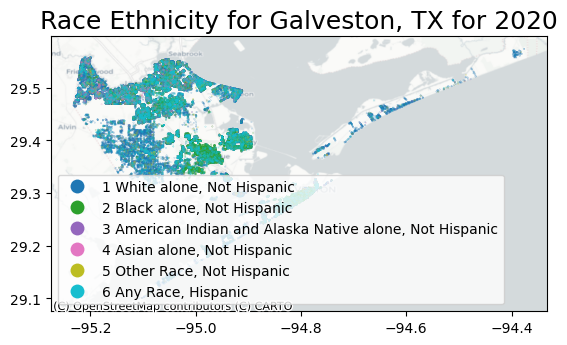

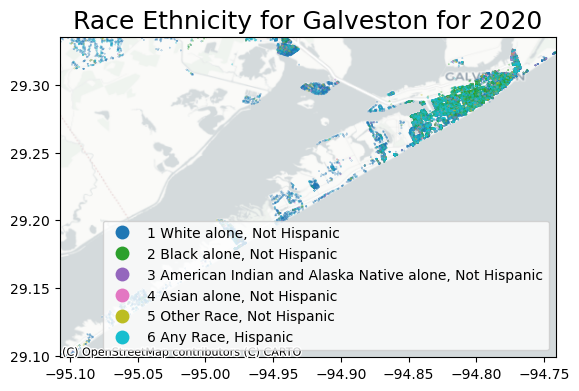

In [25]:

seed_i = 9876

for year in ['2020']:
    # add race ethnicity to data frame for better map legends
    hua_hui_race_gdf_dict[year] = PopResultsTable.add_race_ethnicity_to_pop_df(hua_hui_gdf_dict[year][seed_i])

    #mapname = 'hhincdotmap'
    mapname = f'hhracedotmap_{year}'
    # Map column
    #map_var = 'Household Income Group'
    map_var = 'Race Ethnicity'
    place = focalplace

    yr = str(year)[2:4]
    condition1 = "(hua_hui_race_gdf_dict[year].race >= 1)"
    condition2 = f"(hua_hui_race_gdf_dict[year].placeNAME{yr} == '{place}')"
    conditions = f"{condition1} & {condition2}"

    county_hua_gdf_dict[year] = hua_hui_race_gdf_dict[year].loc[eval(condition1)].copy(deep=True)
    county_hua_gdf_dict[year] = county_hua_gdf_dict[year].to_crs(epsg=4326)
    focal_place_hua_gdf_dict[year] = hua_hui_race_gdf_dict[year].loc[eval(conditions)].copy(deep=True)
    focal_place_hua_gdf_dict[year] = focal_place_hua_gdf_dict[year].to_crs(epsg=4326)

    bldg_inv_id = communities[community_id]['building_inventory']['id']
    outputfolder = 'OutputData_HUA'
    community = communities[community_id]['community_name']

    county_map = plot_dotmap_map(gdf=county_hua_gdf_dict[year],
                            mapname=mapname,
                            map_var=map_var,
                            bldg_inv_id=bldg_inv_id,
                            community=community_id,
                            place = community,
                            year = year,
                            outputfolder=outputfolder,
                            condition_id = "1",
                            basemap_source = cx.providers.CartoDB.Positron)
    
    # get xlim and ylim for focal place
    xlim = [focal_place_hua_gdf_dict[year].total_bounds[0], focal_place_hua_gdf_dict[year].total_bounds[2]]
    ylim = [focal_place_hua_gdf_dict[year].total_bounds[1], focal_place_hua_gdf_dict[year].total_bounds[3]]
    print(xlim, ylim)

    focal_place_map = plot_dotmap_map(gdf=county_hua_gdf_dict[year],
                        mapname=mapname,
                        map_var=map_var,
                        bldg_inv_id=bldg_inv_id,
                        community=community_id,
                        place = focalplace,
                        year = year,
                        outputfolder=outputfolder,
                        condition_id = "2",
                        basemap_source = cx.providers.CartoDB.Positron,
                        xlim = xlim,
                        ylim = ylim,
                        focal_gdf = focal_place_hua_gdf_dict[year])

### Spatial Analysis

In [26]:
# Install individually
# !pip install esda --break-system-packages
# !pip install libpysal --break-system-packages
# !pip install splot --break-system-packages
# !pip install spreg --break-system-packages

In [27]:
# convert county name to string with _ instead of spaces
filename = "Galveston_County_TX_NSI"

# 2nd Workflow: PREC Workflow (Person Records with Disability)

In [28]:
# ==============================================================
# Step 1: Setup — imports and community configuration
# ==============================================================

%load_ext autoreload
%autoreload 2

import os
import pandas as pd
import numpy as np
from IPython.display import display

from pyncoda.ncoda_00g_community_options import *
from pyncoda.CommunitySourceData.api_census_gov.acg_01a_BaseInventory import BaseInventory
from pyncoda.CommunitySourceData.api_census_gov.acg_00f_preci_block2020 import sexbyage_P12_2020_varstem_roots

# --- Community Setup ---
community_id_by_name = 'Galveston, TX: NSI Building inventory for Galveston County, TX'
community_id, focalplace, countyname, countyfips = get_community_id_by_name(community_id_by_name)

state_county      = countyfips
state_county_name = countyname
seed              = 9876
basevintage       = '2020'

# --- Output folders ---
prec_outputfolder = "OutputData_PREC"
prec_base = f"{prec_outputfolder}/{community_id}"

prec_outputfolders = {
    'top'                    : prec_base,
    'logfiles'               : f"{prec_base}/00_logfiles",
    'CommunitySourceData'    : f"{prec_base}/01_CommunitySourceData",
    'TidyCommunitySourceData': f"{prec_base}/02_TidyCommunitySourceData",
    'BaseInventory'          : f"{prec_base}/03_BaseInventory",
    'RandomMerge'            : f"{prec_base}/04_RandomMerge",
}
for folder in prec_outputfolders.values():
    os.makedirs(folder, exist_ok=True)

print(f"Community    : {community_id}")
print(f"State/County : {state_county} — {state_county_name}")
print(f"Seed         : {seed}")
print(f"Base vintage : {basevintage}")
print("Folders ready ✓")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Selected community ID: Galveston_County_TX_NSI
Galveston, TX is in TEXAS
Focal place: Galveston
Galveston, TX is in Galveston County, TX with FIPS code 48167
Use IN-CORE: False
Community    : Galveston_County_TX_NSI
State/County : 48167 — Galveston County, TX
Seed         : 9876
Base vintage : 2020
Folders ready ✓


In [29]:
# ==============================================================
# Monkey-patch BaseInventory.obtain_census_api with retry logic
# Census 2020 DHC API is flaky for block-level P12A-P12I queries
# ==============================================================
import os
import json
import time
import requests
import pandas as pd
from pyncoda.CommunitySourceData.api_census_gov.acg_01a_BaseInventory import BaseInventory
from pyncoda.CommunitySourceData.api_census_gov.acg_00a_createAPI_datastructure import createAPI_datastructure


def obtain_census_api_with_retry(
    state_county: str,
    vintage: str = "2010",
    dataset_name: str = 'dec/sf1',
    get_vars: str = 'GEO_ID',
    var_stem: str = '',
    for_geography: str = 'block:*',
    outputfolders = {'CommunitySourceData' : 'countydata/popinv_workflow'},
):
    """Drop-in replacement for BaseInventory.obtain_census_api with timeout + retry."""
    state  = state_county[0:2]
    county = state_county[2:5]

    json_filename  = f'{var_stem}_{state_county}_{vintage}'
    censusapi_folder = outputfolders['CommunitySourceData'] + '/api_census_gov'
    os.makedirs(censusapi_folder, exist_ok=True)
    json_filepath = censusapi_folder + "/" + json_filename + '.json'

    # Use cached data if available
    if os.path.exists(json_filepath):
        with open(json_filepath) as f:
            data = json.load(f)
        print(f"Dictionary file {json_filepath} Already exists - Skipping API Call.")
        return pd.DataFrame(columns=data[0], data=data[1:])

    api_hyperlink = (
        f'https://api.census.gov/data/{vintage}/{dataset_name}'
        f'?get={get_vars}'
        f'&in=state:{state}&in=county:{county}'
        f'&for={for_geography}'
    )
    print(f"       Census API data from: {api_hyperlink}")

    # Retry up to 5 times with exponential backoff and a 120s timeout per attempt
    last_error = None
    for attempt in range(1, 6):
        try:
            apijson = requests.get(api_hyperlink, timeout=120)
            if apijson.status_code == 200:
                data = apijson.json()
                df = pd.DataFrame(columns=data[0], data=data[1:])
                with open(json_filepath, 'w') as f:
                    json.dump(data, f)
                if attempt > 1:
                    print(f"       Succeeded on attempt {attempt}")
                return df
            else:
                last_error = f"HTTP {apijson.status_code}"
                print(f"       Attempt {attempt}/5 failed: {last_error}. Retrying in {2**attempt}s...")
        except (requests.exceptions.Timeout, requests.exceptions.ConnectionError) as e:
            last_error = type(e).__name__
            print(f"       Attempt {attempt}/5 failed: {last_error}. Retrying in {2**attempt}s...")
        time.sleep(2 ** attempt)  # 2, 4, 8, 16, 32 seconds

    raise Exception(f"Failed to download from Census API after 5 attempts. Last error: {last_error}")


# Install the patch
BaseInventory.obtain_census_api = staticmethod(obtain_census_api_with_retry)
print("✓ BaseInventory.obtain_census_api patched with retry + 120s timeout")

✓ BaseInventory.obtain_census_api patched with retry + 120s timeout


In [30]:
# ==============================================================
# Step 2: Create block-level person records from P12 (Sex by Age)
# ==============================================================
block_df = {}

block_df['preci'] = BaseInventory.get_apidata(
    state_county  = state_county,
    geo_level     = 'block',
    vintage       = basevintage,
    mutually_exclusive_varstems_roots_dictionaries = [sexbyage_P12_2020_varstem_roots],
    outputfolders = prec_outputfolders,
    outputfile    = 'CorePREC'
)

print(f"\nStep 2 complete: Block-level person records created.")
print(f"Shape   : {block_df['preci'].shape}")
print(f"Columns : {list(block_df['preci'].columns)}")
display(block_df['preci'].head(3))

File OutputData_PREC/Galveston_County_TX_NSI/03_BaseInventory/CorePREC_48167_2020.csv Already exists - Skipping API Call.

Step 2 complete: Block-level person records created.
Shape   : (350682, 9)
Columns : ['precid', 'Block2020', 'Block2020str', 'sex', 'minageyrs', 'maxageyrs', 'race', 'hispan', 'prec_counter']


,precid,Block2020,Block2020str,sex,minageyrs,maxageyrs,race,hispan,prec_counter
0,B481677201001000P0001,481677201001000,B481677201001000,1,50,54,1,0,1
1,B481677201001000P0002,481677201001000,B481677201001000,1,50,54,1,0,2
2,B481677201001000P0003,481677201001000,B481677201001000,1,50,54,1,0,3


In [31]:
# ==============================================================
# Step 3: Add Hispanic ethnicity via graft method
# ==============================================================
from pyncoda.CommunitySourceData.api_census_gov.acg_00f_preci_block2020 import (
    sexbyage_P12HAI_2020_varstem_roots,
    hispan_byrace_P5_2020_varstem_roots
)

block_df['precihispan'] = BaseInventory.graft_on_new_char(
    base_inventory        = block_df['preci'],
    state_county          = state_county,
    new_char              = 'hispan',
    new_char_dictionaries = [
        sexbyage_P12HAI_2020_varstem_roots,
        hispan_byrace_P5_2020_varstem_roots
    ],
    basevintage   = '2020',          # ← THE FIX
    outputfile    = 'preci',
    outputfolders = prec_outputfolders
)

print(f"\nStep 3 complete: Hispanic ethnicity added.")
print(f"Shape   : {block_df['precihispan'].shape}")
print(f"Columns : {list(block_df['precihispan'].columns)}")
print(f"\nhispan value counts:")
print(block_df['precihispan']['hispan'].value_counts().sort_index())
display(block_df['precihispan'].head(3))

File OutputData_PREC/Galveston_County_TX_NSI/03_BaseInventory/preci_hispan_48167_2020.csv Already exists with new variable grafted - Skipping API Call.

Step 3 complete: Hispanic ethnicity added.
Shape   : (350682, 24)
Columns : ['precid', 'Block2020', 'Block2020str', 'sex', 'minageyrs', 'maxageyrs', 'race', 'hispan', 'prec_counter', 'hispan_flag', 'hispan_flagset', 'totalprob_hispan', 'hispanbyP12HAI', 'preccount_hispanbyP12HAI', 'sumby_hispanbyP12HAI', 'prob_hispanbyP12HAI', 'hispanbyP5', 'preccount_hispanbyP5', 'sumby_hispanbyP5', 'prob_hispanbyP5', 'hispanbyP12HAI_counter', 'hispanbyP5_counter', 'preccount_hispanbyP12HAIupdated', 'preccount_hispanbyP5updated']

hispan value counts:
hispan
0.0    261883
1.0     88799
Name: count, dtype: int64


,precid,Block2020,Block2020str,sex,minageyrs,maxageyrs,race,hispan,prec_counter,hispan_flag,...,sumby_hispanbyP12HAI,prob_hispanbyP12HAI,hispanbyP5,preccount_hispanbyP5,sumby_hispanbyP5,prob_hispanbyP5,hispanbyP12HAI_counter,hispanbyP5_counter,preccount_hispanbyP12HAIupdated,preccount_hispanbyP5updated
0,B481677201001000P0001,481677201001000.0,B481677201001000,1.0,50.0,54.0,1.0,0.0,1.0,hispan set to 0 by core hui,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,B481677201001000P0002,481677201001000.0,B481677201001000,1.0,50.0,54.0,1.0,0.0,2.0,hispan set to 0 by core hui,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,B481677201001000P0003,481677201001000.0,B481677201001000,1.0,50.0,54.0,1.0,0.0,3.0,hispan set to 0 by core hui,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [32]:
# ==============================================================
# Step 4: Add random age to block and tract records
# ==============================================================

from pyncoda.CommunitySourceData.api_census_gov.acg_02c_agefunctions import (
    add_randage,
    add_P12age_groups
)

# --- Step 4a: Add random age to block-level person records ---
block_df['precihispan'] = add_randage(
    block_df['precihispan'],
    seed    = seed,
    varname = 'randageP12'
)
block_df['precihispan'] = add_P12age_groups(
    block_df['precihispan'],
    varname = 'randageP12'
)

print(f"Step 4a complete: Random age added to block records.")
print(f"Shape      : {block_df['precihispan'].shape}")
print(f"\nrandageP12 sample stats:")
print(block_df['precihispan']['randageP12'].describe())
print(f"\nagegroupP12 value counts:")
print(block_df['precihispan']['agegroupP12'].value_counts().sort_index())

Step 4a complete: Random age added to block records.
Shape      : (350682, 26)

randageP12 sample stats:
count    350682.000000
mean         38.438269
std          23.326843
min           0.000000
25%          18.000000
50%          38.000000
75%          57.000000
max         109.000000
Name: randageP12, dtype: float64

agegroupP12 value counts:
agegroupP12
1.0     19869
2.0     22966
3.0     25228
4.0     15237
5.0      9144
6.0      4397
7.0      4082
8.0     12015
9.0     21087
10.0    22389
11.0    23631
12.0    22465
13.0    22499
14.0    22455
15.0    24786
16.0     9979
17.0    13948
18.0     8590
19.0    11170
20.0    14565
21.0     9146
22.0     5760
23.0     5274
Name: count, dtype: int64


In [33]:
# ==============================================================
# Step 5: Fetch tract-level PCT12 data and add random age
# ==============================================================

tract_df = {}
group = 'PCT12'

# --- Step 5a: Fetch PCT12 variable structure (uses patched 2020-aware function) ---
sexbyage_PCT12_varstem_roots = createAPI_datastructure.obtain_api_metadata(
    vintage      = '2020',
    dataset_name = 'dec/dhc',
    group        = group,
    outputfolder = prec_outputfolder
)

# --- Step 5b: Pull tract-level PCT12 data ---
tract_df['PCT12'] = BaseInventory.get_apidata(
    state_county  = state_county,
    geo_level     = 'tract',
    vintage       = '2020',
    mutually_exclusive_varstems_roots_dictionaries = [sexbyage_PCT12_varstem_roots],
    outputfolders = prec_outputfolders,
    outputfile    = group
)

# --- Step 5c: Add random age to tract records ---
tract_df['PCT12'] = add_randage(
    tract_df['PCT12'],
    seed    = seed,
    varname = 'randagePCT12'
)
tract_df['PCT12'] = add_P12age_groups(
    tract_df['PCT12'],
    varname = 'randagePCT12'
)

print(f"Step 5 complete: Tract-level PCT12 data fetched and age added.")
print(f"Shape   : {tract_df['PCT12'].shape}")
print(f"Columns : {list(tract_df['PCT12'].columns)}")
print(f"\nrandagePCT12 sample stats:")
print(tract_df['PCT12']['randagePCT12'].describe())
display(tract_df['PCT12'].head(3))

Dictionary file OutputData_PREC/00_datastructures/api_census_gov/PCT12_2020_datastructurev0-2-0.txt Already exists - Skipping API Call.
File OutputData_PREC/Galveston_County_TX_NSI/03_BaseInventory/PCT12_48167_2020.csv Already exists - Skipping API Call.
Step 5 complete: Tract-level PCT12 data fetched and age added.
Shape   : (350682, 11)
Columns : ['index', 'GEO_ID', 'state', 'county', 'tract', 'sex', 'minageyrs', 'maxageyrs', 'prec_counter', 'randagePCT12', 'agegroupP12']

randagePCT12 sample stats:
count    350682.000000
mean         38.787272
std          23.009367
min           0.000000
25%          18.000000
50%          39.000000
75%          58.000000
max         108.000000
Name: randagePCT12, dtype: float64


,index,GEO_ID,state,county,tract,sex,minageyrs,maxageyrs,prec_counter,randagePCT12,agegroupP12
0,49,1400000US48167720100,48,167,720100,1,0,0,1,0.0,1.0
1,49,1400000US48167720100,48,167,720100,1,0,0,2,0.0,1.0
2,49,1400000US48167720100,48,167,720100,1,0,0,3,0.0,1.0


In [34]:
# ==============================================================
# Step 6a: Random merge tract age onto block person records
# ==============================================================

from pyncoda.CommunitySourceData.api_census_gov.acg_02a_add_categorical_char import add_new_char_by_random_merge_2dfs

add_age = add_new_char_by_random_merge_2dfs(
    dfs = {
        'primary'  : {'data'       : block_df['precihispan'],
                      'primarykey' : 'precid',
                      'geolevel'   : 'Block',
                      'geovintage' : '2020',
                      'notes'      : 'Block age, sex, race, ethnicity data.'},
        'secondary': {'data'       : tract_df['PCT12'],
                      'primarykey' : 'uniqueidPCT12',
                      'geolevel'   : 'Tract',
                      'geovintage' : '2020',
                      'notes'      : 'Tract single-year age, sex data.'}
    },
    seed              = seed,
    common_group_vars = ['agegroupP12'],
    new_char          = 'randagePCT12',
    geolevel          = 'Tract',
    geovintage        = '2020',
    by_groups         = {'All': {'by_variables': ['sex']}},
    fillna_value      = -999,
    state_county      = state_county,
    outputfile        = 'preci_randomage',
    outputfolder      = prec_outputfolders['RandomMerge']
)

rounds = {'options': {
    'option1': {
        'notes'            : 'By original common group vars and by groups variables.',
        'common_group_vars': add_age.common_group_vars,
        'by_groups'        : add_age.by_groups
    }},
    'geo_levels': ['Tract']
}

prec_age_df = add_age.run_random_merge_2dfs(rounds)

# Sanity check
primary_df = prec_age_df['primary']
print(f"\nStep 6 complete: Tract age merged onto block person records.")
print(f"Shape   : {primary_df.shape}")
print(f"Columns : {list(primary_df.columns)}")
print(f"\nrandagePCT12 assignment flags:")
print(primary_df['randagePCT12_flagsetrm'].value_counts().sort_index())
print(f"\nrandagePCT12 stats:")
print(primary_df['randagePCT12'].describe())
display(primary_df.head(3))

File OutputData_PREC/Galveston_County_TX_NSI/04_RandomMerge/preci_randomage_48167_2020_rs9876_primary.csv Already exists - Skipping Random Merge.
File preci_randomage_48167_2020_rs9876_secondary Already exists - Skipping Random Merge.

Step 6 complete: Tract age merged onto block person records.
Shape   : (350682, 30)
Columns : ['precid', 'Tract2020', 'Block2020', 'Block2020str', 'sex', 'minageyrs', 'maxageyrs', 'race', 'hispan', 'prec_counter', 'hispan_flag', 'hispan_flagset', 'totalprob_hispan', 'hispanbyP12HAI', 'preccount_hispanbyP12HAI', 'sumby_hispanbyP12HAI', 'prob_hispanbyP12HAI', 'hispanbyP5', 'preccount_hispanbyP5', 'sumby_hispanbyP5', 'prob_hispanbyP5', 'hispanbyP12HAI_counter', 'hispanbyP5_counter', 'preccount_hispanbyP12HAIupdated', 'preccount_hispanbyP5updated', 'randageP12', 'agegroupP12', 'randagePCT12', 'randagePCT12_flagsetrm', 'randagePCT12_Tract2020_flagsetrm']

randagePCT12 assignment flags:
randagePCT12_flagsetrm
1    350682
Name: count, dtype: int64

randagePCT12

,precid,Tract2020,Block2020,Block2020str,sex,minageyrs,maxageyrs,race,hispan,prec_counter,...,prob_hispanbyP5,hispanbyP12HAI_counter,hispanbyP5_counter,preccount_hispanbyP12HAIupdated,preccount_hispanbyP5updated,randageP12,agegroupP12,randagePCT12,randagePCT12_flagsetrm,randagePCT12_Tract2020_flagsetrm
0,B481677201001000P0001,48167720100,481677201001000,B481677201001000,1.0,50.0,54.0,1.0,0.0,1.0,...,NaN,NaN,NaN,NaN,NaN,53.0,14.0,50.0,1,1.0
1,B481677201001000P0002,48167720100,481677201001000,B481677201001000,1.0,50.0,54.0,1.0,0.0,2.0,...,NaN,NaN,NaN,NaN,NaN,52.0,14.0,53.0,1,1.0
2,B481677201001000P0003,48167720100,481677201001000,B481677201001000,1.0,50.0,54.0,1.0,0.0,3.0,...,NaN,NaN,NaN,NaN,NaN,53.0,14.0,51.0,1,1.0


In [36]:
# Check vintage, dataset, and structure of all 7 disability tables (B18101–B18107)
from pyncoda.CommunitySourceData.api_census_gov.acg_00h_disability_ACS5yr2022 import (
    disability_B18101_varstem_roots_2022,
    disability_B18102_varstem_roots_2022,
    disability_B18103_varstem_roots_2022,
    disability_B18104_varstem_roots_2022,
    disability_B18105_varstem_roots_2022,
    disability_B18106_varstem_roots_2022,
    disability_B18107_varstem_roots_2022,
)

all_dicts = {
    'B18101 (overall disability)':       disability_B18101_varstem_roots_2022,
    'B18102 (hearing difficulty)':       disability_B18102_varstem_roots_2022,
    'B18103 (vision difficulty)':        disability_B18103_varstem_roots_2022,
    'B18104 (cognitive difficulty)':     disability_B18104_varstem_roots_2022,
    'B18105 (ambulatory difficulty)':    disability_B18105_varstem_roots_2022,
    'B18106 (self-care difficulty)':     disability_B18106_varstem_roots_2022,
    'B18107 (indep. living difficulty)': disability_B18107_varstem_roots_2022,
}

for name, d in all_dicts.items():
    md = d['metadata']
    var_count = len(d[md['group'] + '_'])   # e.g. d['B18101_']
    print(f"{name}")
    print(f"  vintage      : {md['vintage']}")
    print(f"  dataset_name : {md['dataset_name']}")
    print(f"  new_char     : {md['new_char']}")
    print(f"  char_vars    : {md['char_vars']}")
    print(f"  variables    : {var_count} variable codes")
    print()

B18101 (overall disability)
  vintage      : 2022
  dataset_name : acs/acs5
  new_char     : disability
  char_vars    : ['sex', 'agegroupB18101', 'disability']
  variables    : 24 variable codes

B18102 (hearing difficulty)
  vintage      : 2022
  dataset_name : acs/acs5
  new_char     : hearing_difficulty
  char_vars    : ['sex', 'agegroupB18101', 'hearing_difficulty']
  variables    : 24 variable codes

B18103 (vision difficulty)
  vintage      : 2022
  dataset_name : acs/acs5
  new_char     : vision_difficulty
  char_vars    : ['sex', 'agegroupB18101', 'vision_difficulty']
  variables    : 24 variable codes

B18104 (cognitive difficulty)
  vintage      : 2022
  dataset_name : acs/acs5
  new_char     : cognitive_difficulty
  char_vars    : ['sex', 'agegroupB18101', 'cognitive_difficulty']
  variables    : 20 variable codes

B18105 (ambulatory difficulty)
  vintage      : 2022
  dataset_name : acs/acs5
  new_char     : ambulatory_difficulty
  char_vars    : ['sex', 'agegroupB18101', 

In [37]:
import requests

# Test the exact URL the API is calling
url = ("https://api.census.gov/data/2022/acs/acs5"
       "?get=GEO_ID,B18101_004E,B18101_005E"
       "&in=state:48&in=county:167&for=tract:*")

# Also try without underscore (as the code is using)
url2 = ("https://api.census.gov/data/2022/acs/acs5"
        "?get=GEO_ID,B18101004E,B18101005E"
        "&in=state:48&in=county:167&for=tract:*")

r1 = requests.get(url)
print(f"URL with underscore - Status: {r1.status_code}")
print(r1.text[:300])

print()

r2 = requests.get(url2)
print(f"URL without underscore - Status: {r2.status_code}")
print(r2.text[:300])

URL with underscore - Status: 200
[["GEO_ID","B18101_004E","B18101_005E","state","county","tract"],
["1400000US48167720100","0","172","48","167","720100"],
["1400000US48167720200","0","123","48","167","720200"],
["1400000US48167720301","0","67","48","167","720301"],
["1400000US48167720302","0","206","48","167","720302"],
["1400000US

URL without underscore - Status: 400
error: unknown variable 'B18101004E'


In [39]:
# ==============================================================
# Step 6b: Fetch tract-level disability data (B18101–B18107)
# ==============================================================
from pyncoda.CommunitySourceData.api_census_gov.acg_01a_BaseInventory import BaseInventory
from pyncoda.CommunitySourceData.api_census_gov.acg_00h_disability_ACS5yr2022 import (
    disability_B18101_varstem_roots_2022,
    disability_B18102_varstem_roots_2022,
    disability_B18103_varstem_roots_2022,
    disability_B18104_varstem_roots_2022,
    disability_B18105_varstem_roots_2022,
    disability_B18106_varstem_roots_2022,
    disability_B18107_varstem_roots_2022,
)

# All 7 disability tables to fetch
disability_tables = {
    'B18101': disability_B18101_varstem_roots_2022,   # Overall disability
    'B18102': disability_B18102_varstem_roots_2022,   # Hearing difficulty
    'B18103': disability_B18103_varstem_roots_2022,   # Vision difficulty
    'B18104': disability_B18104_varstem_roots_2022,   # Cognitive difficulty
    'B18105': disability_B18105_varstem_roots_2022,   # Ambulatory difficulty
    'B18106': disability_B18106_varstem_roots_2022,   # Self-care difficulty
    'B18107': disability_B18107_varstem_roots_2022,   # Independent living difficulty
}

# Fetch each table from Census API
for group, varstem_dict in disability_tables.items():
    print(f"\n--- Fetching {group} ---")
    tract_df[group] = BaseInventory.get_apidata(
        state_county  = state_county,
        geo_level     = 'tract',
        vintage       = '2022',
        mutually_exclusive_varstems_roots_dictionaries = [varstem_dict],
        outputfolders = prec_outputfolders,
        outputfile    = group
    )
    print(f"{group} fetched. Shape: {tract_df[group].shape}")
    print(f"Columns: {list(tract_df[group].columns)}")
    display(tract_df[group].head(3))

print(f"\n✅ All 7 disability tables fetched successfully")
print(f"Tables in tract_df: {[k for k in tract_df.keys() if k.startswith('B181')]}")


--- Fetching B18101 ---
File OutputData_PREC/Galveston_County_TX_NSI/03_BaseInventory/B18101_48167_2022.csv Already exists - Skipping API Call.
B18101 fetched. Shape: (346041, 9)
Columns: ['index', 'GEO_ID', 'state', 'county', 'tract', 'sex', 'agegroupB18101', 'disability', 'prec_counter']


,index,GEO_ID,state,county,tract,sex,agegroupB18101,disability,prec_counter
0,103,1400000US48167720100,48,167,720100,1,1,0,1
1,103,1400000US48167720100,48,167,720100,1,1,0,2
2,103,1400000US48167720100,48,167,720100,1,1,0,3



--- Fetching B18102 ---
File OutputData_PREC/Galveston_County_TX_NSI/03_BaseInventory/B18102_48167_2022.csv Already exists - Skipping API Call.
B18102 fetched. Shape: (346041, 9)
Columns: ['index', 'GEO_ID', 'state', 'county', 'tract', 'sex', 'agegroupB18101', 'hearing_difficulty', 'prec_counter']


,index,GEO_ID,state,county,tract,sex,agegroupB18101,hearing_difficulty,prec_counter
0,103,1400000US48167720100,48,167,720100,1,1,0,1
1,103,1400000US48167720100,48,167,720100,1,1,0,2
2,103,1400000US48167720100,48,167,720100,1,1,0,3



--- Fetching B18103 ---
File OutputData_PREC/Galveston_County_TX_NSI/03_BaseInventory/B18103_48167_2022.csv Already exists - Skipping API Call.
B18103 fetched. Shape: (346041, 9)
Columns: ['index', 'GEO_ID', 'state', 'county', 'tract', 'sex', 'agegroupB18101', 'vision_difficulty', 'prec_counter']


...


--- Fetching B18106 ---
File OutputData_PREC/Galveston_County_TX_NSI/03_BaseInventory/B18106_48167_2022.csv Already exists - Skipping API Call.
B18106 fetched. Shape: (325361, 9)
Columns: ['index', 'GEO_ID', 'state', 'county', 'tract', 'sex', 'agegroupB18101', 'selfcare_difficulty', 'prec_counter']


,index,GEO_ID,state,county,tract,sex,agegroupB18101,selfcare_difficulty,prec_counter
0,103,1400000US48167720100,48,167,720100,1,2,0,1
1,103,1400000US48167720100,48,167,720100,1,2,0,2
2,103,1400000US48167720100,48,167,720100,1,2,0,3



--- Fetching B18107 ---
File OutputData_PREC/Galveston_County_TX_NSI/03_BaseInventory/B18107_48167_2022.csv Already exists - Skipping API Call.
B18107 fetched. Shape: (262317, 9)
Columns: ['index', 'GEO_ID', 'state', 'county', 'tract', 'sex', 'agegroupB18101', 'indliving_difficulty', 'prec_counter']


,index,GEO_ID,state,county,tract,sex,agegroupB18101,indliving_difficulty,prec_counter
0,0,1400000US48167720100,48,167,720100,1,3,1,1
1,0,1400000US48167720100,48,167,720100,1,3,1,2
2,0,1400000US48167720100,48,167,720100,1,3,1,3



✅ All 7 disability tables fetched successfully
Tables in tract_df: ['B18101', 'B18102', 'B18103', 'B18104', 'B18105', 'B18106', 'B18107']


In [40]:
from pyncoda.CommunitySourceData.api_census_gov.acg_02c_agefunctions import (
    add_randage,
    add_P12age_groups,
    add_B18101age_groups
)

In [41]:
# ==============================================================
# Step 7: Add B18101 age groups to person records (used by all 7 disability tables)
# ==============================================================
prec_age_df['primary'] = add_B18101age_groups(
    prec_age_df['primary'],
    varname = 'randagePCT12'
)
print(f"Step 7 complete!")

print(f"\nPerson records agegroupB18101 value counts:")
print(prec_age_df['primary']['agegroupB18101'].value_counts().sort_index())

# Loop through all 7 disability tables for diagnostics
disability_char_cols = {
    'B18101': 'disability',
    'B18102': 'hearing_difficulty',
    'B18103': 'vision_difficulty',
    'B18104': 'cognitive_difficulty',
    'B18105': 'ambulatory_difficulty',
    'B18106': 'selfcare_difficulty',
    'B18107': 'indliving_difficulty',
}

for table, char_col in disability_char_cols.items():
    print(f"\n--- {table} ---")
    print(f"  Shape: {tract_df[table].shape}")
    print(f"  {char_col} value counts:")
    print(tract_df[table][char_col].value_counts().sort_index())
    print(f"  agegroupB18101 value counts:")
    print(tract_df[table]['agegroupB18101'].value_counts().sort_index())

print(f"\nPerson records shape: {prec_age_df['primary'].shape}")

Step 7 complete!

Person records agegroupB18101 value counts:
agegroupB18101
1.0     19869
2.0     63431
3.0     73114
4.0    139763
5.0     34325
6.0     20180
Name: count, dtype: int64

--- B18101 ---
  Shape: (346041, 9)
  disability value counts:
disability
0    301243
1     44798
Name: count, dtype: int64
  agegroupB18101 value counts:
agegroupB18101
1     20680
2     63044
3     74111
4    137219
5     32410
6     18577
Name: count, dtype: int64

--- B18102 ---
  Shape: (346041, 9)
  hearing_difficulty value counts:
hearing_difficulty
0    332957
1     13084
Name: count, dtype: int64
  agegroupB18101 value counts:
agegroupB18101
1     20680
2     63044
3     74111
4    137219
5     32410
6     18577
Name: count, dtype: int64

--- B18103 ---
  Shape: (346041, 9)
  vision_difficulty value counts:
vision_difficulty
0    336745
1      9296
Name: count, dtype: int64
  agegroupB18101 value counts:
agegroupB18101
1     20680
2     63044
3     74111
4    137219
5     32410
6     18577
Na

In [42]:
# =============================================================
# Step 8: Random Merge ALL 7 Disability Types — UNIVERSE-SAFE
#   Phase A: Generate ONE file per disability type (7 separate files)
#   Phase B: Combine all 7 into a single final file
#
# Universe restrictions enforced via pre-filtering:
#   B18101/B18102/B18103: all ages
#   B18104/B18105/B18106: 5+ years   (agegroupB18101 >= 2)
#   B18107:               18+ years  (agegroupB18101 >= 3)
#
# 4-round merge strategy (within universe only):
#   Round 1: Tract + Sex + AgegroupB18101  (most precise)
#   Round 2: Tract + Sex                   (drop age group)
#   Round 3: Tract only                    (drop sex)
#   Round 4: County only                   (broadest fallback)
# =============================================================
import os
import pandas as pd
from pyncoda.CommunitySourceData.api_census_gov.acg_02a_add_categorical_char import add_new_char_by_random_merge_2dfs

# Map each Census table to (column_name, minimum_eligible_agegroup)
# agegroupB18101: 1=Under5, 2=5-17, 3=18-34, 4=35-64, 5=65-74, 6=75+
disability_tables = {
    'B18101': ('disability',             1),   # all ages
    'B18102': ('hearing_difficulty',     1),   # all ages
    'B18103': ('vision_difficulty',      1),   # all ages
    'B18104': ('cognitive_difficulty',   2),   # 5+ years
    'B18105': ('ambulatory_difficulty',  2),   # 5+ years
    'B18106': ('selfcare_difficulty',    2),   # 5+ years
    'B18107': ('indliving_difficulty',   3),   # 18+ years
}

# Define the 4-round merge strategy (same for all 7 tables)
rounds = {
    'options': {
        'option1': {
            'notes'            : 'Round 1: Tract + Sex + AgegroupB18101 (most precise)',
            'common_group_vars': ['agegroupB18101'],
            'by_groups'        : {'All': {'by_variables': ['sex']}}
        },
        'option2': {
            'notes'            : 'Round 2: Tract + Sex (drop age group)',
            'common_group_vars': [],
            'by_groups'        : {'All': {'by_variables': ['sex']}}
        },
        'option3': {
            'notes'            : 'Round 3: Tract only (drop sex)',
            'common_group_vars': [],
            'by_groups'        : {'All': {'by_variables': []}}
        },
        'option4': {
            'notes'            : 'Round 4: County level (broadest fallback)',
            'common_group_vars': [],
            'by_groups'        : {'All': {'by_variables': []}}
        }
    },
    'geo_levels': ['Tract', 'Tract', 'Tract', 'County']
}

# =============================================================
# PHASE A — Generate one standalone file per disability type
# =============================================================
print("\n" + "="*70)
print("PHASE A: Generating one file per disability type")
print("="*70)

# Base person records (have agegroupB18101 from Step 7) — used as input for each merge
base_df = prec_age_df['primary'].copy()

# Container to hold the result of each disability merge (one entry per table)
disability_results = {}

for table, (char_col, min_agegroup) in disability_tables.items():
    print(f"\n{'─'*70}")
    print(f"[{table}] Merging → '{char_col}'  (universe: agegroup >= {min_agegroup})")
    print(f"{'─'*70}")
    
    # Filter base df to ONLY in-universe records before merging
    eligible_mask = base_df['agegroupB18101'] >= min_agegroup
    eligible_df   = base_df[eligible_mask].copy()
    out_count     = (~eligible_mask).sum()
    
    print(f"  In-universe records:     {len(eligible_df):,}")
    print(f"  Out-of-universe records: {out_count:,} (will be set to -999)")
    
    # 4-round random merge — only on eligible records, no leakage possible
    add_char = add_new_char_by_random_merge_2dfs(
        dfs = {
            'primary':   {'data'      : eligible_df,
                          'primarykey': 'precid',
                          'geolevel'  : 'Block',
                          'geovintage': '2020',
                          'notes'     : f'Eligible person-level data ({char_col})'},
            'secondary': {'data'      : tract_df[table],
                          'primarykey': f'uniqueid{table}',
                          'geolevel'  : 'Tract',
                          'geovintage': '2020',
                          'notes'     : f'Tract-level {table} counts by sex and age'}
        },
        seed              = seed,
        common_group_vars = ['agegroupB18101'],
        new_char          = char_col,
        geolevel          = 'Tract',
        geovintage        = '2020',
        by_groups         = {'All': {'by_variables': ['sex']}},
        fillna_value      = -999,
        state_county      = state_county,
        outputfile        = f'prec_{char_col}',
        outputfolder      = prec_outputfolders['RandomMerge']
    )
    
    merged          = add_char.run_random_merge_2dfs(rounds)
    eligible_result = merged['primary']
    
    # Build the standalone file for THIS disability type:
    #   Start from the FULL base population
    #   Bring in disability_col + flag columns from the eligible result
    #   Out-of-universe records get -999
    new_cols  = [c for c in eligible_result.columns if c not in base_df.columns]
    keep_cols = ['precid'] + new_cols
    
    standalone_df = (
        base_df.set_index('precid')
               .join(eligible_result[keep_cols].set_index('precid'), how='left')
               .reset_index()
    )
    
    # Fill out-of-universe records with -999 for char column AND flag columns
    for col in new_cols:
        standalone_df[col] = standalone_df[col].fillna(-999)
    
    # Save the standalone file for this disability type
    out_path = os.path.join(
        prec_outputfolders['RandomMerge'],
        f'prec_{char_col}_{state_county}_2020_rs{seed}.csv'
    )
    standalone_df.to_csv(out_path, index=False)
    print(f"  Saved → {out_path}")
    
    # Quick verification: universe enforcement
    out_violations = ((standalone_df['agegroupB18101'] < min_agegroup) &
                      (standalone_df[char_col].isin([0, 1]))).sum()
    in_universe   = standalone_df[standalone_df['agegroupB18101'] >= min_agegroup]
    in_assigned   = in_universe[char_col].isin([0, 1]).sum()
    in_with       = (in_universe[char_col] == 1).sum()
    in_rate       = in_assigned / len(in_universe) * 100 if len(in_universe) else 0
    with_rate     = in_with / in_assigned * 100 if in_assigned else 0
    
    status = "✅" if out_violations == 0 else "❌"
    print(f"  {status} Universe violations: {out_violations}")
    print(f"     Within-universe assignment rate: {in_rate:.2f}%")
    print(f"     With-disability rate (in universe): {with_rate:.2f}%")
    print(f"     Value counts:")
    print(standalone_df[char_col].value_counts().sort_index().to_string().replace('\n', '\n     '))
    
    # Stash for Phase B
    disability_results[char_col] = standalone_df[['precid', char_col] + 
                                                  [c for c in new_cols if c != char_col]]

print(f"\n{'='*70}")
print(f"✅ PHASE A COMPLETE: 7 standalone disability files generated")
print(f"{'='*70}")

# =============================================================
# PHASE B — Combine all 7 disability columns into ONE final file
# =============================================================
print("\n" + "="*70)
print("PHASE B: Combining all 7 disability types into one final file")
print("="*70)

# Start with base person records
output_df = base_df.copy()

# Merge each disability result onto the base — only pull the columns
# specifically for that disability type (avoids auxiliary column collisions)
for char_col, sub_df in disability_results.items():
    # Keep only: precid + the char column + columns that explicitly start with char_col_
    # (these are the disability-specific flag columns like 'disability_flagsetrm')
    keep_cols = ['precid'] + [
        c for c in sub_df.columns
        if c == char_col or c.startswith(f'{char_col}_')
    ]
    sub_df_clean = sub_df[keep_cols]
    
    output_df = output_df.merge(sub_df_clean, on='precid', how='left')
    
    # Make sure -999 stays as -999 (not NaN) for the columns we just added
    for col in sub_df_clean.columns:
        if col != 'precid' and col in output_df.columns:
            output_df[col] = output_df[col].fillna(-999)

# Save the combined file
combined_path = os.path.join(
    prec_outputfolders['RandomMerge'],
    f'prec_disability_all_{state_county}_2020_rs{seed}.csv'
)
output_df.to_csv(combined_path, index=False)
print(f"\nFinal combined file saved → {combined_path}")
print(f"Shape: {output_df.shape}")

# Final summary table — universe-aware
print(f"\n{'─'*80}")
print(f"{'Disability Type':<25} {'Universe':<10} {'In-Univ Assigned %':>20} {'With (1) %':>12}")
print(f"{'─'*80}")
universe_labels = {1: 'all ages', 2: '5+ yrs', 3: '18+ yrs'}
for table, (char_col, min_ag) in disability_tables.items():
    in_universe = output_df[output_df['agegroupB18101'] >= min_ag]
    universe_size = len(in_universe)
    assigned = in_universe[char_col].isin([0, 1]).sum()
    assigned_pct = assigned / universe_size * 100 if universe_size else 0
    with_pct = ((in_universe[char_col] == 1).sum() / assigned * 100) if assigned else 0
    print(f"{char_col:<25} {universe_labels[min_ag]:<10} {assigned_pct:>19.2f}% {with_pct:>11.2f}%")

# Verify universe enforcement is clean across all 7 columns
print(f"\n{'─'*80}")
print("Universe enforcement verification:")
print(f"{'─'*80}")
all_clean = True
for table, (char_col, min_ag) in disability_tables.items():
    out_violations = ((output_df['agegroupB18101'] < min_ag) &
                      (output_df[char_col].isin([0, 1]))).sum()
    status = "✅" if out_violations == 0 else "❌"
    if out_violations > 0:
        all_clean = False
    print(f"{status} {char_col:<25}: {out_violations} out-of-universe assignments")

print()
if all_clean:
    print("✅ ALL 7 DISABILITY TYPES PASS UNIVERSE ENFORCEMENT")
else:
    print("❌ SOME DISABILITY TYPES HAVE UNIVERSE VIOLATIONS - REVIEW REQUIRED")

# Show sample
display_cols = ['precid', 'sex', 'agegroupB18101', 'randagePCT12'] + \
               [c for t, (c, m) in disability_tables.items()]
display(output_df[display_cols].head(5))


PHASE A: Generating one file per disability type

──────────────────────────────────────────────────────────────────────
[B18101] Merging → 'disability'  (universe: agegroup >= 1)
──────────────────────────────────────────────────────────────────────
  In-universe records:     350,682
  Out-of-universe records: 0 (will be set to -999)
Round 1
Performing random merge at geography level: Tract
Round 1: Tract + Sex + AgegroupB18101 (most precise)
Running random merge by ['Tract2020', 'sex', 'agegroupB18101']
    Setting up  primary data with primary key and flags
Geolevels available []
Geolvarids available ['Tract2020', 'Block2020']
Adding Tract2020 expected length 11
Dataframe has Block 2020 for new geovar Tract2020
Confirming Tract2020 has expected length.
Checking primary key name precid
Primary key variable precid is unique.
Primary key precid has no missing values
Initializing primary flag set variable for disability
New flag: disability_flagsetrm
['precid', 'Tract2020', 'Block2020'

D:\000_Projects_UH\Disability_HUA-PREC_Workflow\pyncoda\CommunitySourceData\api_census_gov\acg_02a_add_categorical_char.py:765: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.5' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  set_flag_df.loc[conditions, self.flaggeo_var] = .5


0 observations do not have required variable County2020
0 observations do not have required variable sex
0 observations do not have required variable agegroupB18101
0 observations do not have required variable sex
Setting 0 flags for observations without required variable County2020
Setting 0 flags for observations without required variable sex
Setting 0 flags for observations without required variable agegroupB18101
Attempting random merge for 21603 primary observations.
    Preparing primary by All data for random merge.
Sorting by  ['precid']
Sorting before random merge order by ['County2020', 'sex', 'agegroupB18101', 'random_order']
Generating random merge order by ['County2020', 'sex', 'agegroupB18101']
    Setting up  secondary data with primary key and flags
Geolevels available ['state', 'county', 'tract']
Geolvarids available ['Tract2020']
Adding County2020 expected length 5
Dataframe has Tract 2020 for new geovar County2020
Confirming County2020 has expected length.
Checking p

D:\000_Projects_UH\Disability_HUA-PREC_Workflow\pyncoda\CommunitySourceData\api_census_gov\acg_02a_add_categorical_char.py:765: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.5' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  set_flag_df.loc[conditions, self.flaggeo_var] = .5


Sorting before random merge order by ['County2020', 'sex', 'agegroupB18101', 'random_order']
Generating random merge order by ['County2020', 'sex', 'agegroupB18101']
    Setting up  secondary data with primary key and flags
Geolevels available ['state', 'county', 'tract']
Geolvarids available ['Tract2020']
Adding County2020 expected length 5
Dataframe has Tract 2020 for new geovar County2020
Confirming County2020 has expected length.
Checking primary key name uniqueidB18102
Primary key variable uniqueidB18102 is unique.
Primary key uniqueidB18102 has no missing values
['uniqueidB18102', 'County2020', 'Tract2020', 'index', 'GEO_ID', 'state', 'county', 'tract', 'sex', 'agegroupB18101', 'prec_counter', 'hearing_difficulty', 'randagePCT12_flagsetrm', 'randagePCT12_Tract2020_flagsetrm', 'hearing_difficulty_flagsetrm', 'hearing_difficulty_Tract2020_flagsetrm']
Initializing geovar flag set variable for hearing_difficulty at geolevel County2020
New flag: hearing_difficulty_County2020_flagsetrm

...

D:\000_Projects_UH\Disability_HUA-PREC_Workflow\pyncoda\CommunitySourceData\api_census_gov\acg_02a_add_categorical_char.py:765: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.5' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  set_flag_df.loc[conditions, self.flaggeo_var] = .5


Geolevels available ['state', 'county', 'tract']
Geolvarids available ['Tract2020']
Adding County2020 expected length 5
Dataframe has Tract 2020 for new geovar County2020
Confirming County2020 has expected length.
Checking primary key name uniqueidB18106
Primary key variable uniqueidB18106 is unique.
Primary key uniqueidB18106 has no missing values
['uniqueidB18106', 'County2020', 'Tract2020', 'index', 'GEO_ID', 'state', 'county', 'tract', 'sex', 'agegroupB18101', 'prec_counter', 'selfcare_difficulty', 'randagePCT12_flagsetrm', 'randagePCT12_Tract2020_flagsetrm', 'selfcare_difficulty_flagsetrm', 'selfcare_difficulty_Tract2020_flagsetrm']
Initializing geovar flag set variable for selfcare_difficulty at geolevel County2020
New flag: selfcare_difficulty_County2020_flagsetrm
Observations without primary flag set 15086
Observations without geovar flag set 325361
After updated observations without geovar flag set 15086
Setting 15086 flags for selfcare_difficulty secondary data not used.
0 ob

D:\000_Projects_UH\Disability_HUA-PREC_Workflow\pyncoda\CommunitySourceData\api_census_gov\acg_02a_add_categorical_char.py:765: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.5' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  set_flag_df.loc[conditions, self.flaggeo_var] = .5


0 observations do not have required variable County2020
0 observations do not have required variable sex
0 observations do not have required variable agegroupB18101
0 observations do not have required variable sex
Setting 0 flags for observations without required variable County2020
Setting 0 flags for observations without required variable sex
Setting 0 flags for observations without required variable agegroupB18101
Attempting random merge for 15601 primary observations.
    Preparing primary by All data for random merge.
Sorting by  ['precid']
Sorting before random merge order by ['County2020', 'sex', 'agegroupB18101', 'random_order']
Generating random merge order by ['County2020', 'sex', 'agegroupB18101']
    Setting up  secondary data with primary key and flags
Geolevels available ['state', 'county', 'tract']
Geolvarids available ['Tract2020']
Adding County2020 expected length 5
Dataframe has Tract 2020 for new geovar County2020
Confirming County2020 has expected length.
Checking p

,precid,sex,agegroupB18101,randagePCT12,disability,hearing_difficulty,vision_difficulty,cognitive_difficulty,ambulatory_difficulty,selfcare_difficulty,indliving_difficulty
0,B481677201001000P0001,1.0,4.0,50.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,B481677201001000P0002,1.0,4.0,53.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,B481677201001000P0003,1.0,4.0,51.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,B481677201001000P0004,1.0,4.0,50.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,B481677201001000P0005,1.0,4.0,50.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
